<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


In [14]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

#### Import the required libraries we need for the lab.


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Add your code below following the instructions given in the course to complete the peer graded assignment


#### Read the dataset in the csv file from the URL


In [16]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [17]:
# Use the 'boston_url' variable you created in the previous cell
boston_df = pd.read_csv(boston_url)

# Display the first five rows
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [18]:
##Question 2
boston_df.dtypes

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

In [25]:
##Question 3
boston_df.isnull().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

In [27]:
##Question 4
boston_df.duplicated().sum()

0

In [28]:
# Question 5
boston_df.corr()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,0.258465,-0.226604
CRIM,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626


In [34]:
##Question 6
corr_matrix = boston_df.corr()
print(corr_matrix)

            Unnamed: 0      CRIM        ZN     INDUS      CHAS       NOX  \
Unnamed: 0    1.000000  0.407407 -0.103393  0.399439 -0.003759  0.398736   
CRIM          0.407407  1.000000 -0.200469  0.406583 -0.055892  0.420972   
ZN           -0.103393 -0.200469  1.000000 -0.533828 -0.042697 -0.516604   
INDUS         0.399439  0.406583 -0.533828  1.000000  0.062938  0.763651   
CHAS         -0.003759 -0.055892 -0.042697  0.062938  1.000000  0.091203   
NOX           0.398736  0.420972 -0.516604  0.763651  0.091203  1.000000   
RM           -0.079971 -0.219247  0.311991 -0.391676  0.091251 -0.302188   
AGE           0.203784  0.352734 -0.569537  0.644779  0.086518  0.731470   
DIS          -0.302211 -0.379670  0.664408 -0.708027 -0.099176 -0.769230   
RAD           0.686002  0.625505 -0.311948  0.595129 -0.007368  0.611441   
TAX           0.666626  0.582764 -0.314563  0.720760 -0.035587  0.668023   
PTRATIO       0.291074  0.289946 -0.391679  0.383248 -0.121515  0.188933   
LSTAT       

In [35]:
# To see the WHOLE thing without it being cut off (the "..." in the middle)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(boston_df)



,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.5380,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.4690,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.4690,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.4580,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.4580,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
5,5,0.02985,0.0,2.18,0.0,0.4580,6.430,58.7,6.0622,3.0,222.0,18.7,5.21,28.7
6,6,0.08829,12.5,7.87,0.0,0.5240,6.012,66.6,5.5605,5.0,311.0,15.2,12.43,22.9
7,7,0.14455,12.5,7.87,0.0,0.5240,6.172,96.1,5.9505,5.0,311.0,15.2,19.15,27.1
8,8,0.21124,12.5,7.87,0.0,0.5240,5.631,100.0,6.0821,5.0,311.0,15.2,29.93,16.5
9,9,0.17004,12.5,7.87,0.0,0.5240,6.004,85.9,6.5921,5.0,311.0,15.2,17.10,18.9


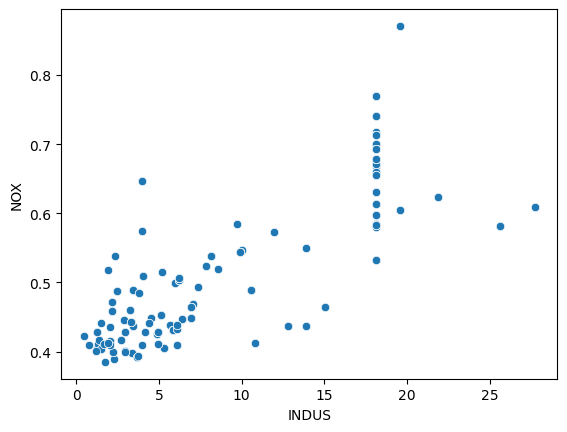

In [38]:
## QUESTION 8

sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
pyplot.show()
##THERE IS A POSITIVE CORELATION

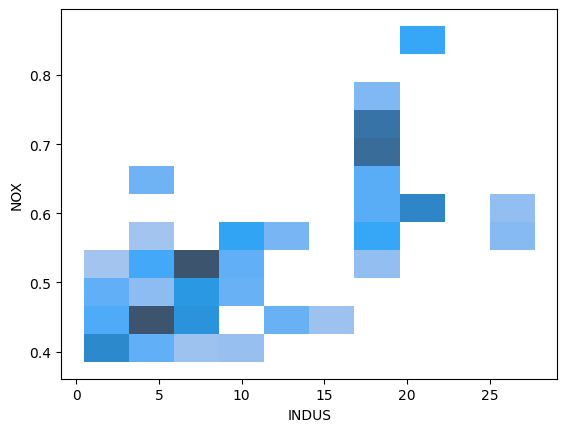

In [40]:
## QUESTION 9

sns.histplot(x='INDUS', y='NOX', data=boston_df)
pyplot.show()


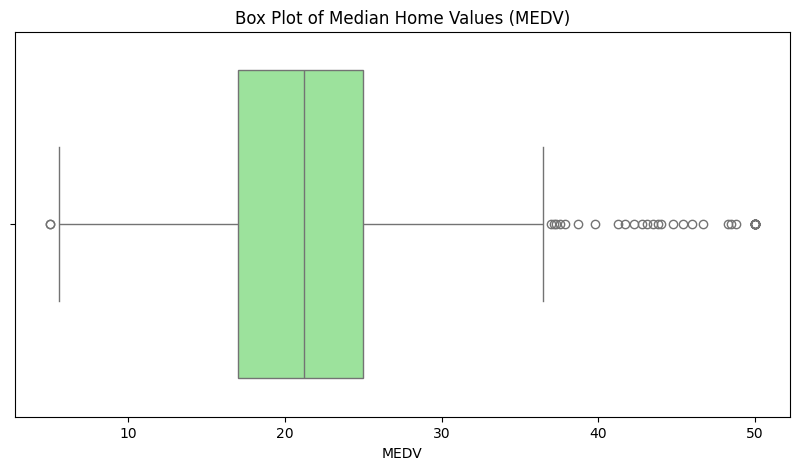

In [42]:
##Question 10

pyplot.figure(figsize=(10, 5))
sns.boxplot(x=boston_df['MEDV'], color='lightgreen')
pyplot.title('Box Plot of Median Home Values (MEDV)')
pyplot.show()

##Concentated results with interqaurtile range the green area and median value 21

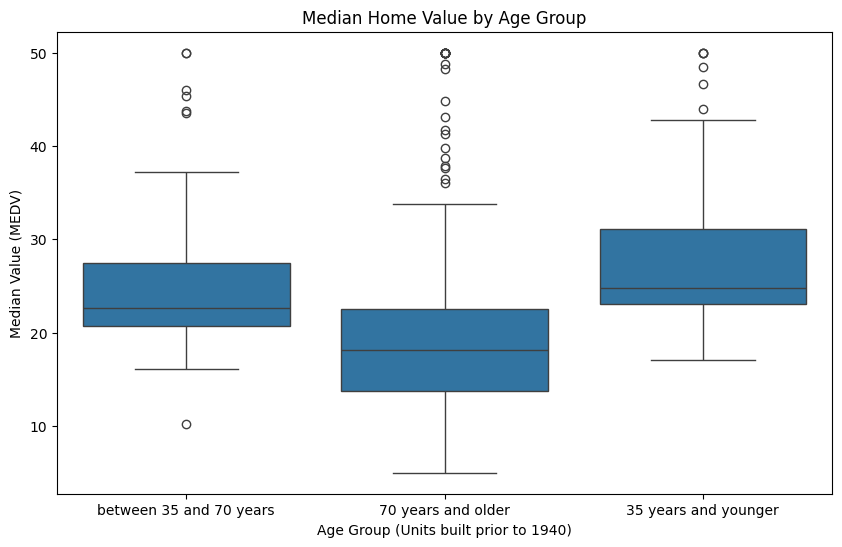

In [44]:
##QUESTION 11
boston_df.loc[(boston_df['AGE'] <= 35), 'age_group'] = '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35)&(boston_df['AGE'] < 70), 'age_group'] = 'between 35 and 70 years'
boston_df.loc[(boston_df['AGE'] >= 70), 'age_group'] = '70 years and older'

pyplot.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='MEDV', data=boston_df)

pyplot.title('Median Home Value by Age Group')
pyplot.xlabel('Age Group (Units built prior to 1940)')
pyplot.ylabel('Median Value (MEDV)')
pyplot.show()

##According to the box plot younger buyers tend to buy more xpsnsive houses

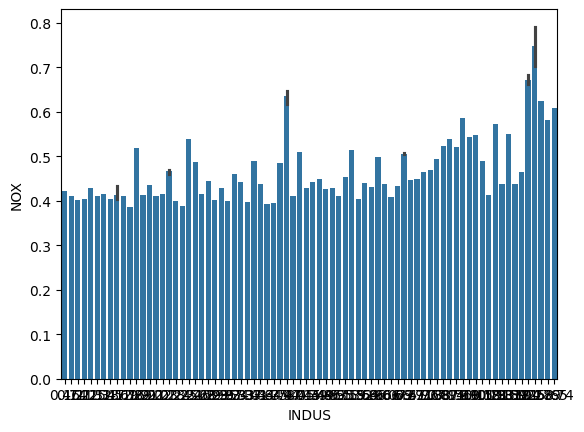

In [45]:
##Question 12
sns.barplot(x='INDUS', y='NOX', data=boston_df)
pyplot.show()

#Higher NOX  values ar eobserved as the value of INDUX increases

13. The most common Python library used to perform Levene’s test is SciPy 
Function: scipy.stats.levene()

14. Levene's test is used to assess the equality of variances for a variable calculated for two or more groups. 
It tests the null hypothesis that the population variances are equal. 

15. A T-test checks for a significant difference between the means of two groups. 


16. Hypotheses of ANOVA: is used to compare means across three or more groups

17. Pearson Correlation Coefficient:measures the strength and direction of the linear relationship between two continuous variables.It ranges from -1 (perfect negative linear relationship) to +1 (perfect positive linear relationship), with 0 indicating no linear relationship.

18. Slope in Linear Regression: it represents the average change in the dependent variable for every  increase in the independent variable and  the rate of change.